In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
order_history = pd.read_csv('order_history.csv')
labels = pd.read_csv('labels.csv')

In [3]:
order_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      800 non-null    int64  
 1   retail_id       800 non-null    object 
 2   order_date      800 non-null    object 
 3   order_value     800 non-null    float64
 4   carton_count    800 non-null    float64
 5   line_of_factor  800 non-null    float64
 6   order_rank      800 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 43.9+ KB


In [4]:
order_history.head()

,Unnamed: 0,retail_id,order_date,order_value,carton_count,line_of_factor,order_rank
0,143864,R_c339ff4c4e8f,1/4/2025,0.003694,0.027273,0.065934,1
1,152984,R_9abdde6e1640,1/6/2025,0.012636,0.045455,0.109890,1
2,152497,R_963d4c1a6ec5,1/6/2025,0.017974,0.081818,0.197802,1
3,257099,R_3df565a6a535,1/7/2025,0.004937,0.013636,0.010989,1
4,143866,R_c339ff4c4e8f,1/7/2025,0.004226,0.022727,0.032967,3


In [5]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   retail_id   200 non-null    object 
 2   class       120 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.8+ KB


In [6]:
labels.head()

,Unnamed: 0,retail_id,class
0,0,R_002acad30d17,1.0
1,1,R_011da1723877,1.0
2,2,R_02594d5e71d2,1.0
3,3,R_04a49dd3a12d,1.0
4,4,R_0551da2ede69,1.0


In [7]:
# count missing values in each col
order_history.isnull().sum()

Unnamed: 0        0
retail_id         0
order_date        0
order_value       0
carton_count      0
line_of_factor    0
order_rank        0
dtype: int64

In [8]:
# basis stats for numerical cols
order_history.describe()

,Unnamed: 0,order_value,carton_count,line_of_factor,order_rank
count,800.000000,800.000000,800.000000,800.000000,800.000000
mean,169799.910000,0.021047,0.045068,0.065865,2.500000
std,60153.264525,0.035797,0.059234,0.079288,1.118733
min,768.000000,0.000000,0.000000,0.000000,1.000000
25%,158080.750000,0.005750,0.018182,0.021978,1.750000
50%,173147.500000,0.010105,0.027273,0.043956,2.500000
75%,191349.500000,0.020029,0.050000,0.076923,3.250000
max,261285.000000,0.509284,0.540909,0.868132,4.000000


In [9]:
# count ditinct users
order_history['retail_id'].nunique()

200

In [10]:
# class distribution in labels
labels['class'].value_counts(dropna=False)

class
1.0    105
NaN     80
0.0     15
Name: count, dtype: int64

In [11]:
# check if every user has 4 orders
orders_per_user = order_history.groupby('retail_id').size()
orders_per_user.value_counts()

4    200
Name: count, dtype: int64

In [12]:
# visual style
sns.set_theme(style="whitegrid")

# convert order_date to datetime
order_history['order_date'] = pd.to_datetime(order_history['order_date'])

# drop unwanted columns
order_history = order_history.drop(columns=['Unnamed: 0'])
labels = labels.drop(columns=['Unnamed: 0'])

Text(0.5, 1.0, 'dist of target class')

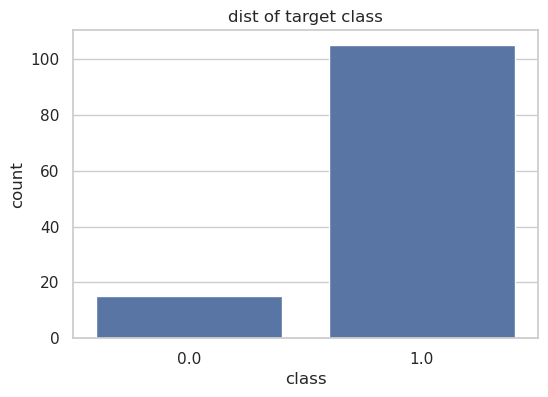

In [13]:
# class dist vis
plt.figure(figsize=(6, 4))
sns.countplot(data=labels.dropna(), x='class')
plt.title('dist of target class')

Text(0.5, 1.0, 'dist of line of factor')

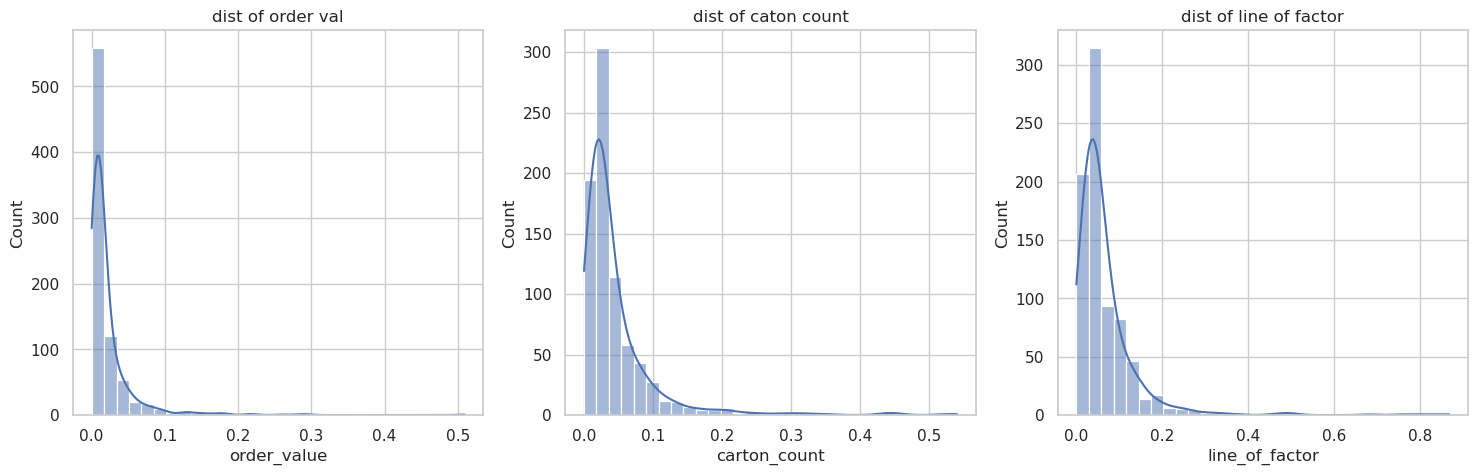

In [14]:
# dist of numerical cols
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(order_history['order_value'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('dist of order val')

sns.histplot(order_history['carton_count'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('dist of caton count')

sns.histplot(order_history['line_of_factor'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('dist of line of factor')

Text(0.5, 1.0, 'corr matrix of features')

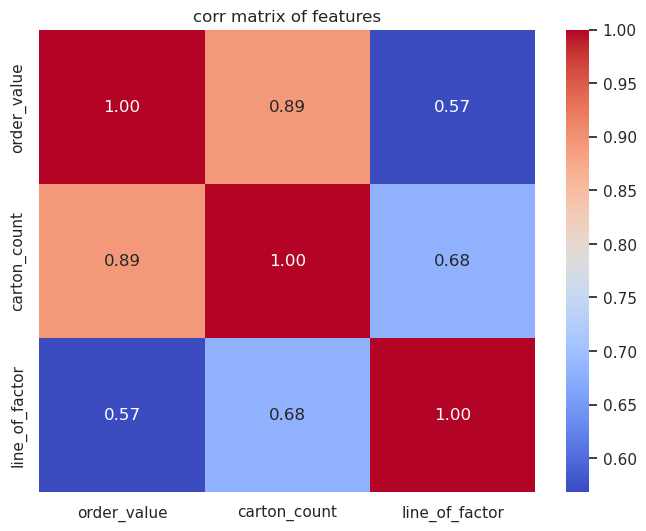

In [15]:
# corr matrix
plt.figure(figsize=(8, 6))
correlation = order_history[['order_value', 'carton_count', 'line_of_factor']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('corr matrix of features')

In [16]:
correlation

,order_value,carton_count,line_of_factor
order_value,1.000000,0.893168,0.568750
carton_count,0.893168,1.000000,0.678697
line_of_factor,0.568750,0.678697,1.000000


##### Feature Eng

In [17]:
# aggs
X_features = order_history.groupby('retail_id').agg({
    'order_value': ['mean', 'sum', 'std', 'max'],
    'carton_count': ['mean', 'std'],
    'line_of_factor': ['mean', 'std']
})

In [18]:
# col names
X_features.columns = ['_'.join(col).strip() for col in X_features.columns.values]
X_features = X_features.reset_index()

In [19]:
X_features.head(2)

,retail_id,order_value_mean,order_value_sum,order_value_std,order_value_max,carton_count_mean,carton_count_std,line_of_factor_mean,line_of_factor_std
0,R_002acad30d17,0.165596,0.662386,0.087745,0.285496,0.338636,0.147266,0.653846,0.189594
1,R_011da1723877,0.043140,0.172560,0.004318,0.048219,0.080682,0.007763,0.137363,0.036446


In [20]:
order_history = order_history.sort_values(['retail_id', 'order_rank'])

In [21]:
# calculating purchase intervals
order_history['prev_order_date'] = order_history.groupby('retail_id')['order_date'].transform(lambda x: x.shift(1))
order_history['interval'] = (order_history['order_date'] - order_history['prev_order_date']).dt.days

In [22]:
order_history.head(2)

,retail_id,order_date,order_value,carton_count,line_of_factor,order_rank,prev_order_date,interval
570,R_002acad30d17,2025-08-13,0.285496,0.540909,0.868132,1,NaT,NaN
594,R_002acad30d17,2025-08-25,0.107867,0.222727,0.483516,2,2025-08-13,12.0


In [23]:
time_features = order_history.groupby('retail_id').agg(
    total_duration=('order_date', lambda x: (x.max() - x.min()).days),
    avg_interval=('interval', 'mean'),
    last_interval=('interval', 'last'),
    first_value=('order_value', 'first'),
    last_value=('order_value', 'last')
).reset_index()

In [24]:
time_features.head(2)

,retail_id,total_duration,avg_interval,last_interval,first_value,last_value
0,R_002acad30d17,38,12.666667,20.0,0.285496,0.092939
1,R_011da1723877,28,9.333333,8.0,0.040200,0.048219


In [25]:
time_features['growth_rate'] = (time_features['last_value'] - time_features['first_value']) / (time_features['first_value'] + 1e-6)

In [26]:
time_features = time_features.drop(columns=['first_value', 'last_value'])

In [27]:
time_features.head(2)

,retail_id,total_duration,avg_interval,last_interval,growth_rate
0,R_002acad30d17,38,12.666667,20.0,-0.674462
1,R_011da1723877,28,9.333333,8.0,0.199462


In [28]:
# Merges
full_dataset = pd.merge(X_features, time_features, on='retail_id', how='left')

# adding labels
full_dataset = pd.merge(full_dataset, labels[['retail_id', 'class']], on='retail_id', how='left')


In [29]:
full_dataset.head(3)

,retail_id,order_value_mean,order_value_sum,order_value_std,order_value_max,carton_count_mean,carton_count_std,line_of_factor_mean,line_of_factor_std,total_duration,avg_interval,last_interval,growth_rate,class
0,R_002acad30d17,0.165596,0.662386,0.087745,0.285496,0.338636,0.147266,0.653846,0.189594,38,12.666667,20.0,-0.674462,1.0
1,R_011da1723877,0.043140,0.172560,0.004318,0.048219,0.080682,0.007763,0.137363,0.036446,28,9.333333,8.0,0.199462,1.0
2,R_02594d5e71d2,0.017103,0.068412,0.012570,0.032619,0.030682,0.018323,0.071429,0.042560,46,15.333333,23.0,5.509571,1.0


In [30]:
# Second implementaion
def create_features(df):

    # agg features
    features = df.groupby('retail_id').agg({
        'order_value': ['mean', 'sum', 'std', 'max'],
        'carton_count': ['mean', 'std'],
        'line_of_factor': ['mean', 'std']
    })
    
    # col names
    features.columns = ['_'.join(col).strip() for col in features.columns.values]
    features = features.reset_index()

    
    def extract_time_logic(group):
        group = group.sort_values('order_rank')
        dates = group['order_date'].tolist()
        values = group['order_value'].tolist()
        
        # shop intervals
        intervals = [(dates[i] - dates[i-1]).days for i in range(1, len(dates))]
        
        
        total_duration = (dates[-1] - dates[0]).days 
        avg_interval = np.mean(intervals)            
        last_interval = intervals[-1]                
        
        
        growth_rate = (values[-1] - values[0]) / (values[0] + 1e-6)
        
        return pd.Series({
            'total_duration': total_duration,
            'avg_interval': avg_interval,
            'last_interval': last_interval,
            'growth_rate': growth_rate
        })

    
    time_features = df.groupby('retail_id').apply(extract_time_logic).reset_index()

    
    final_features = pd.merge(features, time_features, on='retail_id')
    return final_features


X_features = create_features(order_history)
full_dataset = pd.merge(X_features, labels[['retail_id', 'class']], on='retail_id', how='left')

In [31]:
full_dataset.head(2)

,retail_id,order_value_mean,order_value_sum,order_value_std,order_value_max,carton_count_mean,carton_count_std,line_of_factor_mean,line_of_factor_std,total_duration,avg_interval,last_interval,growth_rate,class
0,R_002acad30d17,0.165596,0.662386,0.087745,0.285496,0.338636,0.147266,0.653846,0.189594,38.0,12.666667,20.0,-0.674462,1.0
1,R_011da1723877,0.043140,0.172560,0.004318,0.048219,0.080682,0.007763,0.137363,0.036446,28.0,9.333333,8.0,0.199462,1.0


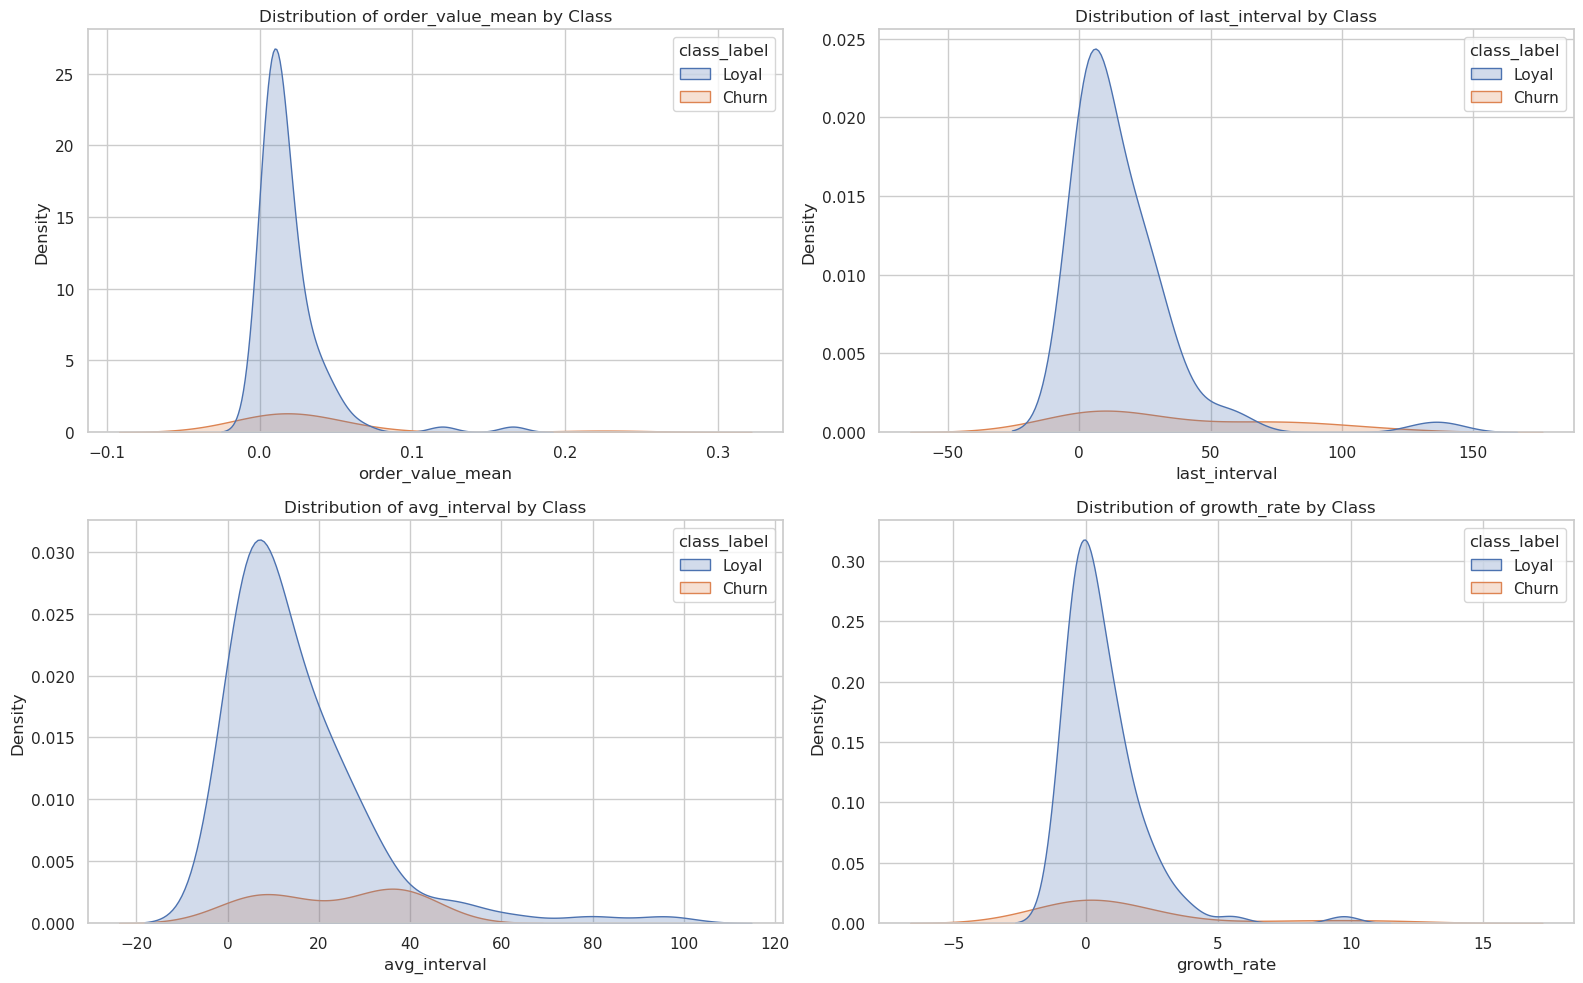

In [32]:
labeled_df = full_dataset.dropna(subset=['class']).copy()
labeled_df['class_label'] = labeled_df['class'].map({1.0: 'Loyal', 0.0: 'Churn'})
labeled_df = labeled_df[(labeled_df['last_interval'] >= 0) & (labeled_df['avg_interval'] >= 0)]

# cols to compare
features_to_compare = ['order_value_mean', 'last_interval', 'avg_interval', 'growth_rate']

plt.figure(figsize=(16, 10))

for i, feature in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=labeled_df, x=feature, hue='class_label', fill=True)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [33]:
comparison_stats = labeled_df.groupby('class_label')[features_to_compare].mean()
comparison_stats

,order_value_mean,last_interval,avg_interval,growth_rate
class_label,,,,
Churn,0.033762,35.866667,23.511111,1.573108
Loyal,0.018600,15.980952,15.250794,0.628632


In [34]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   retail_id            200 non-null    object 
 1   order_value_mean     200 non-null    float64
 2   order_value_sum      200 non-null    float64
 3   order_value_std      200 non-null    float64
 4   order_value_max      200 non-null    float64
 5   carton_count_mean    200 non-null    float64
 6   carton_count_std     200 non-null    float64
 7   line_of_factor_mean  200 non-null    float64
 8   line_of_factor_std   200 non-null    float64
 9   total_duration       200 non-null    float64
 10  avg_interval         200 non-null    float64
 11  last_interval        200 non-null    float64
 12  growth_rate          200 non-null    float64
 13  class                120 non-null    float64
dtypes: float64(13), object(1)
memory usage: 22.0+ KB


In [35]:
full_dataset.to_csv('full_dataset.csv', index=False)